# XAI vs No XAI Comparison - IC50 MPro Task

Comparing the effect of explainable AI (XAI) guidance on molecule optimization performance for IC50 prediction against SARS-CoV-2 Main Protease (MPro).

**Note**: For IC50, lower values are better. Only molecules with QED ≥ 0.6 are considered valid; molecules below this threshold are assigned a penalty score.


In [10]:
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [11]:
# Define paths
RESULTS_DIR = Path("../../data/results/ic50mpro_qed")

# Penalty value for molecules with QED < 0.6 (in nM)
# Using 1,000,000 nM (1 mM) as a high but finite penalty
QED_PENALTY_IC50 = 1_000_000
QED_THRESHOLD = 0.6

# Define experiment groups: (display_name, folder_name)
GROUPS = [
    ("Claude Opus 4.5 (Full XAI)", "claude-opus-4.5_full_xai"),
    ("Claude Opus 4.5 (Partial XAI)", "claude-opus-4.5_partial_xai"),
    ("Claude Opus 4.5 (No XAI)", "claude-opus-4.5_no_xai"),
    ("Claude Opus 4.5 (No description)", "claude-opus-4.5_no_description"),
]


## Loading Data


In [12]:
def load_trace(p: Path) -> list:
    """Load trace from JSON file."""
    d = json.loads(p.read_text(encoding="utf-8"))
    return d["trace"] if isinstance(d, dict) and "trace" in d else d


def load_results_as_df(results_dir: Path, groups: list, qed_threshold: float, penalty: float) -> pd.DataFrame:
    """Load all results from JSON trace files into a DataFrame.
    
    For molecules with QED < qed_threshold, the IC50 score is replaced with a penalty value.
    
    Returns DataFrame with columns: model, replicate, iteration, score, effective_score, qed, smiles
    """
    rows = []
    
    for display_name, folder_name in groups:
        folder_path = results_dir / folder_name
        files = sorted(folder_path.glob("ic50mpro_qed_*.json"))
        
        if not files:
            print(f"Warning: No files in {folder_path} matching ic50mpro_qed_*.json")
            continue
        
        for file_path in files:
            # Extract replicate number from filename (e.g., "rep1", "rep2")
            rep_match = re.search(r'rep(\d+)', file_path.name)
            replicate = int(rep_match.group(1)) if rep_match else 0
            
            try:
                trace = load_trace(file_path)
                for entry in trace:
                    ic50_score = float(entry["score"])
                    qed = float(entry["scores"]["QED"])
                    
                    # Apply penalty for molecules with QED below threshold
                    effective_score = ic50_score if qed >= qed_threshold else penalty
                    
                    rows.append({
                        "model": display_name,
                        "replicate": replicate,
                        "iteration": int(entry["iteration"]),
                        "score": ic50_score,
                        "effective_score": effective_score,
                        "qed": qed,
                        "smiles": entry["smiles"],
                    })
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
    
    return pd.DataFrame(rows)


# Load all results
df = load_results_as_df(RESULTS_DIR, GROUPS, QED_THRESHOLD, QED_PENALTY_IC50)
print(f"Loaded {len(df)} rows from {df['model'].nunique()} model configurations")
print(f"Replicates per model: {df.groupby('model')['replicate'].nunique().to_dict()}")
print(f"\nRows per model:")
print(df.groupby('model').size())
df.head(10)


Loaded 866 rows from 4 model configurations
Replicates per model: {'Claude Opus 4.5 (Full XAI)': 5, 'Claude Opus 4.5 (No XAI)': 5, 'Claude Opus 4.5 (No description)': 5, 'Claude Opus 4.5 (Partial XAI)': 5}

Rows per model:
model
Claude Opus 4.5 (Full XAI)          155
Claude Opus 4.5 (No XAI)            248
Claude Opus 4.5 (No description)    249
Claude Opus 4.5 (Partial XAI)       214
dtype: int64


,model,replicate,iteration,score,effective_score,qed,smiles
0,Claude Opus 4.5 (Full XAI),1,1,105461.554688,1000000.000000,0.500646,CC(C)CC(NC(=O)C(Cc1ccccc1)NC(=O)OC(C)(C)C)C(O)...
1,Claude Opus 4.5 (Full XAI),1,2,7475.554199,7475.554199,0.940085,Cc1cc(F)ccc1NC(=O)C2CC(C)(C)CN2c1ncccn1
2,Claude Opus 4.5 (Full XAI),1,3,6780.401855,6780.401855,0.909801,Fc1ccc(NC(=O)c2csc(N3CCNCC3)n2)cc1
3,Claude Opus 4.5 (Full XAI),1,4,614.412109,614.412109,0.917133,Cc1nc(N2CCOCC2)sc1C(=O)Nc1ccc(F)c(Cl)c1
4,Claude Opus 4.5 (Full XAI),1,5,562.613647,562.613647,0.903062,Cc1nc(N2CCN(C)CC2)sc1C(=O)Nc1ccc(F)c(Cl)c1
5,Claude Opus 4.5 (Full XAI),1,6,1946.964966,1946.964966,0.883622,Cc1nc(N2CCSCC2)sc1C(=O)Nc1ccc(F)c(Cl)c1
6,Claude Opus 4.5 (Full XAI),1,7,1010.559509,1010.559509,0.942027,CN(C)c1nc(C(=O)Nc2ccc(F)c(Cl)c2)c(C)s1
7,Claude Opus 4.5 (Full XAI),1,8,634.697815,634.697815,0.838617,CN1CCC(Nc2nc(C(=O)Nc3ccc(F)c(Cl)c3)c(C)s2)CC1
8,Claude Opus 4.5 (Full XAI),1,9,2236.723145,2236.723145,0.669817,Cc1nc(N2CCN(c3ccccn3)CC2)sc1C(=O)Nc1ccc(F)c(Cl)c1
9,Claude Opus 4.5 (Full XAI),1,10,3944.561768,3944.561768,0.915403,Cc1nc(N2CCCC2)sc1C(=O)Nc1ccc(F)c(Cl)c1


In [13]:
# Check QED distribution and how many molecules pass the threshold
qed_stats = df.groupby('model').agg(
    total_molecules=('qed', 'count'),
    qed_above_threshold=('qed', lambda x: (x >= QED_THRESHOLD).sum()),
    qed_below_threshold=('qed', lambda x: (x < QED_THRESHOLD).sum()),
    mean_qed=('qed', 'mean'),
).round(3)
qed_stats['pct_valid'] = (qed_stats['qed_above_threshold'] / qed_stats['total_molecules'] * 100).round(1)
print(f"QED threshold: {QED_THRESHOLD}")
qed_stats


QED threshold: 0.6


,total_molecules,qed_above_threshold,qed_below_threshold,mean_qed,pct_valid
model,,,,,
Claude Opus 4.5 (Full XAI),155,150,5,0.816,96.8
Claude Opus 4.5 (No XAI),248,189,59,0.691,76.2
Claude Opus 4.5 (No description),249,67,182,0.554,26.9
Claude Opus 4.5 (Partial XAI),214,199,15,0.760,93.0


In [14]:
# Check for runs with fewer than expected iterations
run_lengths = df.groupby(['model', 'replicate'])['iteration'].max()
expected_iterations = run_lengths.max()
short_runs = run_lengths[run_lengths < expected_iterations]

print(f"Expected iterations: {expected_iterations}")
if len(short_runs) > 0:
    print(f"\nFound {len(short_runs)} runs with fewer than {expected_iterations} iterations:")
    print(short_runs.sort_values())
else:
    print(f"All runs have {expected_iterations} iterations")


Expected iterations: 50

Found 8 runs with fewer than 50 iterations:
model                          replicate
Claude Opus 4.5 (Partial XAI)  5            20
Claude Opus 4.5 (Full XAI)     2            23
                               5            24
                               1            29
                               4            29
Claude Opus 4.5 (Partial XAI)  4            45
Claude Opus 4.5 (No XAI)       3            49
Claude Opus 4.5 (Partial XAI)  3            49
Name: iteration, dtype: int64


---
## Best-so-far Progression Plot

For IC50 (lower is better), we use cumulative minimum. Molecules with QED < 0.6 are assigned a penalty score.


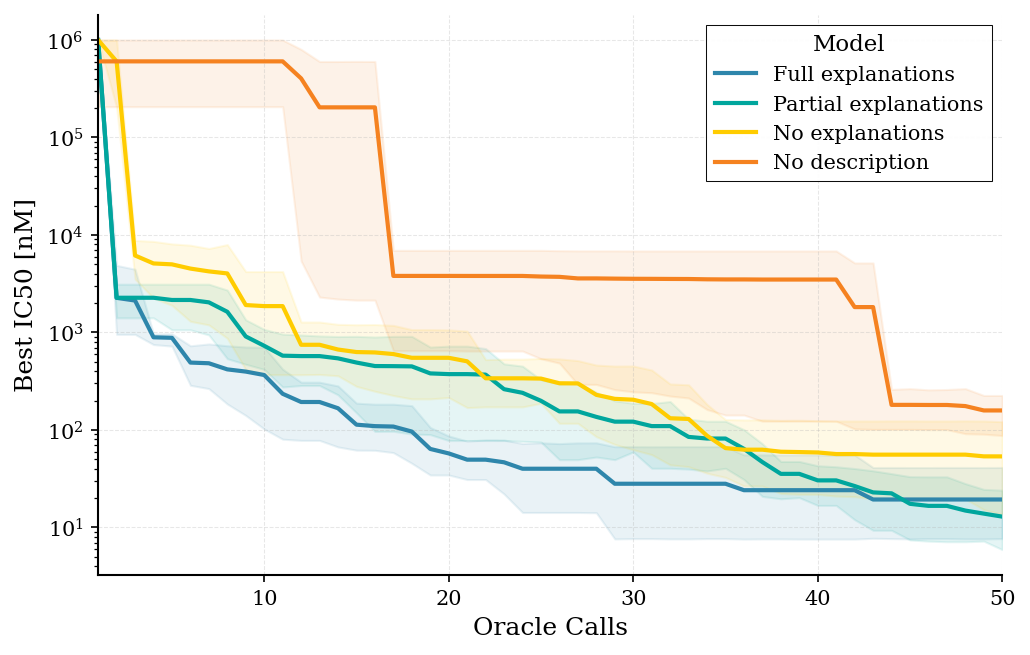

In [15]:
# Compute best-so-far using cummin (for IC50, lower is better)
# Using effective_score which has penalty applied for QED < threshold
df["best_so_far"] = (
    df.sort_values("iteration")
    .groupby(["model", "replicate"])["effective_score"]
    .cummin()
)

# Pivot so each run is a column, forward-fill to handle runs ending early
max_iter = 50  # Limit to 50 iterations
all_iterations = range(1, max_iter + 1)
df_plot = (
    df[df["iteration"] <= max_iter]
    .pivot_table(index="iteration", columns=["model", "replicate"], values="best_so_far")
    .reindex(all_iterations)
    .ffill()
    .melt(ignore_index=False)
    .reset_index()
)

# Set publication-quality style
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (6, 4),
    'axes.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'lines.linewidth': 2.0,
})

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

# Define color palette for explanation conditions
model_colors = {
    'Claude Opus 4.5 (Full XAI)': '#2E86AB',
    'Claude Opus 4.5 (Partial XAI)': '#00a69d',
    'Claude Opus 4.5 (No XAI)': '#ffcc00',
    'Claude Opus 4.5 (No description)': '#f58220',
}

# Define legend order and labels
legend_order = [
    'Claude Opus 4.5 (Full XAI)',
    'Claude Opus 4.5 (Partial XAI)',
    'Claude Opus 4.5 (No XAI)',
    'Claude Opus 4.5 (No description)',
]

legend_labels = {
    'Claude Opus 4.5 (Full XAI)': 'Full explanations',
    'Claude Opus 4.5 (Partial XAI)': 'Partial explanations',
    'Claude Opus 4.5 (No XAI)': 'No explanations',
    'Claude Opus 4.5 (No description)': 'No description',
}

# Plot with seaborn (mean + 95% bootstrap CI)
sns.lineplot(
    data=df_plot, 
    x="iteration", 
    y="value", 
    hue="model",
    hue_order=legend_order,
    palette=model_colors,
    errorbar=('ci', 95),
    err_kws={'alpha': 0.1},  # Make confidence interval more transparent
    linewidth=2.0,
    ax=ax
)

# Styling
ax.set_xlabel("Oracle Calls", fontsize=12, fontweight='normal')
ax.set_ylabel("Best IC50 [nM]", fontsize=12, fontweight='normal')
ax.set_xlim(1, 50)
# Use log scale for IC50 as values can span several orders of magnitude
ax.set_yscale('log')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Improve legend with renamed labels
handles, labels = ax.get_legend_handles_labels()
new_labels = [legend_labels.get(label, label) for label in labels]
legend = ax.legend(
    handles,
    new_labels,
    title='Model',
    frameon=True,
    fancybox=False,
    shadow=False,
    framealpha=0.95,
    edgecolor='black',
    loc='upper right'
)
legend.get_frame().set_linewidth(0.5)

plt.tight_layout()

# Save figure as PDF
plt.savefig('./figures/xai_vs_no_xai_ic50mpro.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()


---
## Iteration to Reach IC50 Threshold

Finding the first iteration where the best-so-far IC50 drops below a target threshold (only for molecules with QED ≥ 0.6).


In [16]:
# Target IC50 threshold in nM (lower is better)
IC50_THRESHOLD = 100  # nM

def first_iteration_below_threshold(group, threshold=IC50_THRESHOLD):
    """Return first iteration where best_so_far <= threshold, or NaN if never reached.
    
    For IC50, lower is better, so we check for values BELOW the threshold.
    """
    below = group[group["best_so_far"] <= threshold]
    if len(below) > 0:
        return below["iteration"].min()
    return np.nan


def bootstrap_ci(data, n_bootstrap=10000, ci=0.95):
    """Compute bootstrap 95% CI for the mean."""
    data = data.dropna()
    if len(data) < 2:
        return np.nan, np.nan
    result = stats.bootstrap(
        (data.values,), 
        statistic=np.mean, 
        n_resamples=n_bootstrap, 
        confidence_level=ci,
        random_state=42
    )
    return result.confidence_interval.low, result.confidence_interval.high


# Compute for each model and replicate
iter_to_threshold = (
    df
    .groupby(["model", "replicate"])
    .apply(first_iteration_below_threshold, include_groups=False)
    .reset_index(name="iter_to_threshold")
)

# Summarize by model with bootstrap CI
summary_rows = []
for model, group in iter_to_threshold.groupby("model"):
    values = group["iter_to_threshold"]
    mean_val = values.mean()
    ci_low, ci_high = bootstrap_ci(values)
    n_total = len(values)
    never_reached = values.isna().sum()
    success_rate = (n_total - never_reached) / n_total * 100
    summary_rows.append({
        "Model": model,
        "Mean Iteration": mean_val,
        "CI 95% Low": ci_low,
        "CI 95% High": ci_high,
        "N": n_total,
        "Never Reached": never_reached,
        "Success Rate (%)": success_rate
    })

threshold_summary = pd.DataFrame(summary_rows).set_index("Model").round(2)

print(f"Iteration to reach IC50 ≤ {IC50_THRESHOLD} nM threshold (with QED ≥ {QED_THRESHOLD}) — 95% Bootstrap CI")
threshold_summary


Iteration to reach IC50 ≤ 100 nM threshold (with QED ≥ 0.6) — 95% Bootstrap CI


,Mean Iteration,CI 95% Low,CI 95% High,N,Never Reached,Success Rate (%)
Model,,,,,,
Claude Opus 4.5 (Full XAI),17.2,11.80,31.00,5,0,100.0
Claude Opus 4.5 (No XAI),28.5,26.75,30.25,5,1,80.0
Claude Opus 4.5 (No description),34.0,NaN,NaN,5,4,20.0
Claude Opus 4.5 (Partial XAI),27.6,18.60,34.72,5,0,100.0


---
## AUC Top-1 over 50 Iterations

For IC50 (lower is better), lower AUC indicates better performance.


In [17]:
def compute_auc_top1_ic50(group_df, max_oracle_calls=50, penalty=QED_PENALTY_IC50):
    """Compute AUC of top-1 (best) IC50 score vs oracle calls from a dataframe group.
    
    For IC50, lower is better, so we track the cumulative minimum.
    
    Args:
        group_df: DataFrame with 'effective_score' and 'iteration' columns for a single run
        max_oracle_calls: Maximum number of oracle calls (default 50)
        penalty: Starting penalty value for runs with no valid molecules yet
    
    Returns:
        AUC value (lower is better for IC50)
    """
    sorted_df = group_df.sort_values('iteration')
    
    best_score = penalty  # Start with penalty (worst case)
    best_at_call = {}
    
    for _, row in sorted_df.iterrows():
        oracle_call = int(row['iteration'])
        score = float(row['effective_score'])
        
        if oracle_call > max_oracle_calls:
            break
        
        # For IC50, lower is better
        if score < best_score:
            best_score = score
        
        best_at_call[oracle_call] = best_score
    
    if not best_at_call:
        # No data points within max_oracle_calls
        return penalty * max_oracle_calls
    
    oracle_calls = sorted(best_at_call.keys())
    
    # Compute AUC as sum of rectangles (left Riemann sum for step function)
    auc = 0.0
    prev_call = 0
    prev_best = penalty  # Start at penalty before first call
    
    for call in oracle_calls:
        auc += prev_best * (call - prev_call)
        prev_call = call
        prev_best = best_at_call[call]
    
    # Extend to max_oracle_calls
    auc += prev_best * (max_oracle_calls - prev_call)
    
    # Normalize by max_oracle_calls to get average best-so-far score
    return auc / max_oracle_calls


# Compute AUC Top-1 for each model/replicate
MAX_ORACLE_CALLS = 50

auc_records = []
for (model, replicate), group in df.groupby(['model', 'replicate']):
    auc = compute_auc_top1_ic50(group, MAX_ORACLE_CALLS)
    auc_records.append({
        'model': model,
        'replicate': replicate,
        'auc_top1': auc
    })

auc_df = pd.DataFrame(auc_records)

# Summarize by model with bootstrap CI
auc_summary_rows = []
for model, group in auc_df.groupby('model'):
    values = group['auc_top1']
    mean_val = values.mean()
    ci_low, ci_high = bootstrap_ci(values)
    # Compute distances from mean to CI bounds
    ci_low_dist = mean_val - ci_low  # Distance below mean
    ci_high_dist = ci_high - mean_val  # Distance above mean
    auc_summary_rows.append({
        "Model": model,
        "Mean AUC Top-1 (nM)": mean_val,
        "CI 95% -": ci_low_dist,
        "CI 95% +": ci_high_dist,
        "N": len(values),
    })

auc_summary = pd.DataFrame(auc_summary_rows).set_index("Model").round(1)

print(f"AUC Top-1 (IC50 in nM) over {MAX_ORACLE_CALLS} iterations — lower is better")
print(f"Penalty for QED < {QED_THRESHOLD}: {QED_PENALTY_IC50:,} nM")
print()
auc_summary


AUC Top-1 (IC50 in nM) over 50 iterations — lower is better
Penalty for QED < 0.6: 1,000,000 nM



,Mean AUC Top-1 (nM),CI 95% -,CI 95% +,N
Model,,,,
Claude Opus 4.5 (Full XAI),40209.9,90.1,122.8,5
Claude Opus 4.5 (No XAI),52958.9,8245.6,7882.9,5
Claude Opus 4.5 (No description),179019.6,109240.0,105216.5,5
Claude Opus 4.5 (Partial XAI),40485.3,256.2,229.6,5


---
## Final Best Scores

Best IC50 achieved by iteration 50 (only for molecules with QED ≥ 0.6).


In [18]:
# Get final best score for each run
final_scores = (
    df[df['iteration'] <= 50]
    .groupby(['model', 'replicate'])
    .agg(
        final_best_ic50=('best_so_far', 'min'),
        final_best_raw_ic50=('score', 'min'),
        best_qed=('qed', 'max'),
    )
    .reset_index()
)

# Summarize by model
final_summary_rows = []
for model, group in final_scores.groupby('model'):
    values = group['final_best_ic50']
    # For runs that never found QED >= 0.6, the value will be the penalty
    valid_runs = values[values < QED_PENALTY_IC50]
    
    mean_val = valid_runs.mean() if len(valid_runs) > 0 else np.nan
    ci_low, ci_high = bootstrap_ci(valid_runs) if len(valid_runs) >= 2 else (np.nan, np.nan)
    
    final_summary_rows.append({
        "Model": model,
        "Mean Best IC50 (nM)": mean_val,
        "CI 95% Low": ci_low,
        "CI 95% High": ci_high,
        "Min IC50 (nM)": valid_runs.min() if len(valid_runs) > 0 else np.nan,
        "N Valid Runs": len(valid_runs),
        "N Total Runs": len(group),
    })

final_summary = pd.DataFrame(final_summary_rows).set_index("Model").round(2)

print(f"Final best IC50 at iteration 50 (for molecules with QED ≥ {QED_THRESHOLD}) — lower is better")
final_summary


Final best IC50 at iteration 50 (for molecules with QED ≥ 0.6) — lower is better


,Mean Best IC50 (nM),CI 95% Low,CI 95% High,Min IC50 (nM),N Valid Runs,N Total Runs
Model,,,,,,
Claude Opus 4.5 (Full XAI),19.33,8.08,51.77,6.53,5,5
Claude Opus 4.5 (No XAI),53.50,17.34,155.63,9.12,5,5
Claude Opus 4.5 (No description),158.41,87.55,225.35,41.68,5,5
Claude Opus 4.5 (Partial XAI),12.90,6.50,28.85,5.02,5,5
